In [11]:
# Basic data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical measures
from scipy.stats import skew, kurtosis

# For better plot aesthetics
%matplotlib inline
sns.set(style="whitegrid")

In [12]:
# Set your file paths
inflation_path = r"D:\Masters Study Abroad\BA 2nd Sem\IS6611 Applied Research in Business Analytics\IS6611 IT Artefact V3\Final Files\Final Datasets\US Inflation Raw\US_inflation_index.csv"
stocks_path = r"D:\Masters Study Abroad\BA 2nd Sem\IS6611 Applied Research in Business Analytics\IS6611 IT Artefact V3\Final Files\Final Datasets\NASDAQ Datasets\NASDAQ_100_final_timezone_fixed.csv"
diff_stocks_path = r"D:\Masters Study Abroad\BA 2nd Sem\IS6611 Applied Research in Business Analytics\IS6611 IT Artefact V3\Old Datasets\combined_dataset.csv"

# Load the data
inflation_df = pd.read_csv(inflation_path)
stocks_df = pd.read_csv(stocks_path)
diff_stocks_df = pd.read_csv(diff_stocks_path)

# View first few rows
print("Inflation Dataset:")
display(inflation_df.head())

print("\nNASDAQ Stocks Dataset:")
display(stocks_df.head())

print("\nCountry Stocks Dataset:")
display(diff_stocks_df.head())


Inflation Dataset:


,Date,Food_Index,Energy_Index,Housing_Index,Food_Growth_%,Energy_Growth_%,Housing_Growth_%
0,2015-01-01,232.167,190.941,242.358,0.00,0.00,0.00
1,2015-02-01,232.601,195.436,242.026,0.19,2.35,-0.14
2,2015-03-01,232.900,204.335,240.896,0.32,7.01,-0.60
3,2015-04-01,233.139,203.430,240.587,0.42,6.54,-0.73
4,2015-05-01,233.512,214.808,240.200,0.58,12.50,-0.89



NASDAQ Stocks Dataset:


,Date,AAPL_CLOSE,AAPL_VOLUME,MSFT_CLOSE,MSFT_VOLUME,AMZN_CLOSE,AMZN_VOLUME,NVDA_CLOSE,NVDA_VOLUME,META_CLOSE,...,VRSN_CLOSE,VRSN_VOLUME,ULTA_CLOSE,ULTA_VOLUME,NXPI_CLOSE,NXPI_VOLUME,CHKP_CLOSE,CHKP_VOLUME,INCY_CLOSE,INCY_VOLUME
0,2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,27.332500,212818400.0,46.759998,27913900.0,15.4260,55664000.0,0.50325,113680000.0,78.449997,...,57.189999,684500.0,126.839996,410800.0,76.809998,2566600.0,78.459999,569000.0,73.760002,775100.0
2,2015-01-05,26.562500,257142000.0,46.330002,39673900.0,15.1095,55484000.0,0.49475,197952000.0,77.190002,...,56.240002,874400.0,127.150002,477400.0,76.000000,3929600.0,78.010002,720800.0,74.220001,968900.0
3,2015-01-06,26.565001,263188400.0,45.650002,36447900.0,14.7645,70380000.0,0.47975,197764000.0,76.150002,...,55.180000,1289300.0,126.949997,758200.0,72.379997,4099700.0,77.949997,1641600.0,71.489998,2249200.0
4,2015-01-07,26.937500,160423600.0,46.230000,29114100.0,14.9210,52806000.0,0.47850,321808000.0,76.150002,...,55.639999,552400.0,130.580002,597200.0,74.330002,2713000.0,78.589996,751700.0,74.449997,1009100.0



Country Stocks Dataset:


,Date,FTSE SmallCap,FTSE AllShare,FTSE 100,Open_NASDAQ,High_NASDAQ,Low_NASDAQ,NASDAQ_Close/Last,Open_NIFTY,High_NIFTY,Low_NIFTY,NIFTY_Close_x
0,05-05-2015,4655.603034,3744.864385,6927.577143,4464.21,4472.23,4407.27,4409.39,8338.4,8355.65,8280.60,8324.8
1,06-05-2015,4666.584641,3746.500378,6933.738160,4420.30,4429.96,4349.93,4379.75,8316.6,8331.95,8083.00,8097
2,07-05-2015,4629.012340,3726.246393,6886.949673,4377.81,4413.73,4373.29,4401.55,8077.0,8122.60,7997.15,8057.3
3,08-05-2015,4695.349833,3814.448611,7046.823511,4445.00,4466.17,4441.73,4458.65,8131.5,8224.95,8123.45,8191.5
4,11-05-2015,4720.115680,3805.483209,7029.849401,4457.62,4468.75,4437.53,4438.64,8243.2,8332.75,8224.65,8325.25


In [13]:
# Check for null values
print("\nMissing Values in Stock Dataset:")
print(stocks_df.isnull().sum())

# Basic statistics
print("\nInflation Dataset Description:")
display(inflation_df.describe())

print("\nStock Dataset Description:")
display(stocks_df.describe())



Missing Values in Stock Dataset:
Date             0
AAPL_CLOSE     102
AAPL_VOLUME    102
MSFT_CLOSE     102
MSFT_VOLUME    102
              ... 
NXPI_VOLUME    102
CHKP_CLOSE     102
CHKP_VOLUME    102
INCY_CLOSE     102
INCY_VOLUME    102
Length: 163, dtype: int64

Inflation Dataset Description:


,Food_Index,Energy_Index,Housing_Index,Food_Growth_%,Energy_Growth_%,Housing_Growth_%
count,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000
mean,275.398840,233.936728,262.302984,18.620800,22.517680,8.229520
std,33.154844,40.299804,28.147695,14.280607,21.106202,11.614265
min,232.167000,170.132000,235.574000,0.000000,-10.900000,-2.800000
25%,248.900000,200.968000,239.371000,7.210000,5.250000,-1.230000
50%,266.266000,220.361000,244.363000,14.690000,15.410000,0.830000
75%,304.389000,273.396000,298.119000,31.110000,43.180000,23.010000
max,341.783000,344.210000,312.738000,47.210000,80.270000,29.040000



Stock Dataset Description:


,AAPL_CLOSE,AAPL_VOLUME,MSFT_CLOSE,MSFT_VOLUME,AMZN_CLOSE,AMZN_VOLUME,NVDA_CLOSE,NVDA_VOLUME,META_CLOSE,META_VOLUME,...,VRSN_CLOSE,VRSN_VOLUME,ULTA_CLOSE,ULTA_VOLUME,NXPI_CLOSE,NXPI_VOLUME,CHKP_CLOSE,CHKP_VOLUME,INCY_CLOSE,INCY_VOLUME
count,2643.000000,2.643000e+03,2643.000000,2.643000e+03,2643.000000,2.643000e+03,2643.000000,2.643000e+03,2643.000000,2.643000e+03,...,2643.000000,2.643000e+03,2643.000000,2.643000e+03,2643.000000,2.643000e+03,2643.000000,2.643000e+03,2643.000000,2.643000e+03
mean,102.128895,1.142434e+08,199.062406,2.859042e+07,106.355797,7.464513e+07,25.947135,4.576918e+08,242.069130,2.254758e+07,...,163.042898,7.533012e+05,309.597779,9.483256e+05,144.896390,3.348878e+06,120.156591,1.091351e+06,82.509175,1.671152e+06
std,68.749007,6.813450e+07,130.397494,1.323344e+07,57.697646,4.040517e+07,39.079487,2.525000e+08,148.566780,1.467073e+07,...,58.124494,4.446596e+05,102.302096,7.530695e+05,55.119442,3.145376e+06,33.412932,6.587011e+05,19.170209,1.313966e+06
min,22.584999,2.323470e+07,40.290001,7.164500e+06,14.347500,1.500750e+07,0.478500,5.244800e+07,74.050003,4.726100e+06,...,54.299999,1.399000e+05,126.839996,2.400000e+05,64.000000,4.805000e+05,72.760002,1.793000e+05,51.180000,1.821000e+05
25%,38.484999,6.822510e+07,73.260002,2.030915e+07,49.353001,4.911600e+07,3.702250,2.944190e+08,139.675003,1.416980e+07,...,101.000000,4.957000e+05,232.900002,5.796500e+05,98.134998,1.939050e+06,102.079998,7.129000e+05,68.419998,1.079850e+06
50%,77.385002,9.697010e+07,174.380005,2.538480e+07,96.715500,6.375400e+07,7.092500,4.060320e+08,186.630005,1.897220e+07,...,184.949997,6.404000e+05,293.040009,7.636000e+05,120.449997,2.627100e+06,115.760002,9.304000e+05,78.480003,1.401600e+06
75%,163.759995,1.395220e+08,299.500000,3.290680e+07,158.788002,8.819400e+07,24.491000,5.515060e+08,302.930008,2.597840e+07,...,207.455002,8.810500e+05,387.945007,1.045050e+06,194.455002,3.734300e+06,127.820000,1.272750e+06,91.540001,1.865650e+06
max,259.019989,6.488252e+08,498.839996,1.691640e+08,242.059998,4.771220e+08,160.000000,3.692928e+09,738.090027,2.323166e+08,...,289.079987,6.831000e+06,567.179993,1.602910e+07,290.779999,5.310220e+07,233.470001,9.141200e+06,152.660004,3.319300e+07


In [15]:
# Load the dataset
diff_stocks_path = r"D:\Masters Study Abroad\BA 2nd Sem\IS6611 Applied Research in Business Analytics\IS6611 IT Artefact V3\Old Datasets\combined_dataset.csv"
diff_stocks_df = pd.read_csv(diff_stocks_path)

# Keep only relevant columns
diff_stocks_df = diff_stocks_df[['Date', 'FTSE 100', 'NASDAQ_Close/Last', 'NIFTY_Close_x']]

# Rename columns
diff_stocks_df.rename(columns={
    'FTSE 100': 'FTSE_100_Close_Price',
    'NASDAQ_Close/Last': 'NASDAQ_100_Close_Price',
    'NIFTY_Close_x': 'NIFTY_100_Close_Price'
}, inplace=True)


# Round numeric columns to 2 decimal places
cols_to_round = ['FTSE_100_Close_Price', 'NASDAQ_100_Close_Price', 'NIFTY_100_Close_Price']
diff_stocks_df[cols_to_round] = diff_stocks_df[cols_to_round].round(2)

# Preview cleaned and rounded dataframe
print("Cleaned & Rounded Dataset:")
display(diff_stocks_df.head())


Cleaned & Rounded Dataset:


,Date,FTSE_100_Close_Price,NASDAQ_100_Close_Price,NIFTY_100_Close_Price
0,05-05-2015,6927.58,4409.39,8324.8
1,06-05-2015,6933.74,4379.75,8097
2,07-05-2015,6886.95,4401.55,8057.3
3,08-05-2015,7046.82,4458.65,8191.5
4,11-05-2015,7029.85,4438.64,8325.25


<Figure size 1200x500 with 0 Axes>

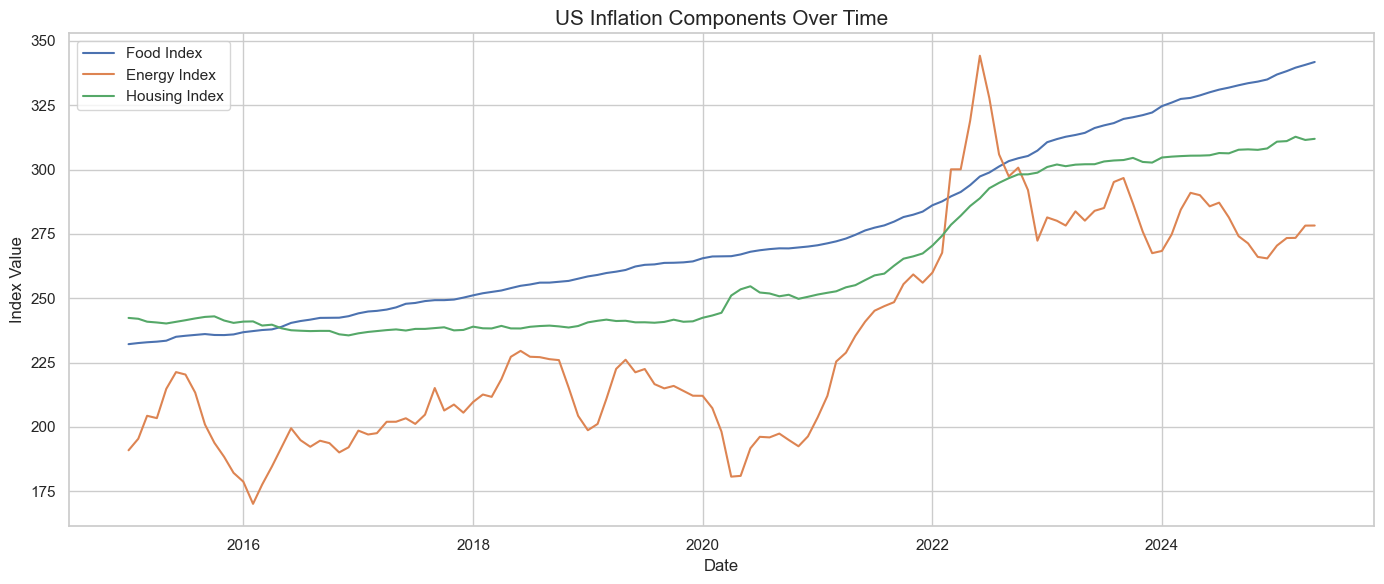

In [18]:
# Ensure 'Date' is datetime and sorted
inflation_df['Date'] = pd.to_datetime(inflation_df['Date'])
inflation_df = inflation_df.sort_values('Date')

# Plot all three indices
plt.figure(figsize=(14, 6))
plt.plot(inflation_df['Date'], inflation_df['Food_Index'], label='Food Index')
plt.plot(inflation_df['Date'], inflation_df['Energy_Index'], label='Energy Index')
plt.plot(inflation_df['Date'], inflation_df['Housing_Index'], label='Housing Index')

plt.title('US Inflation Components Over Time', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Index Value', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
# Convert 'Date' column to datetime with dayfirst=True
diff_stocks_df['Date'] = pd.to_datetime(diff_stocks_df['Date'], dayfirst=True, errors='coerce')

# Drop any rows where date couldn't be parsed
diff_stocks_df = diff_stocks_df.dropna(subset=['Date'])

# Sort by Date
diff_stocks_df = diff_stocks_df.sort_values('Date')


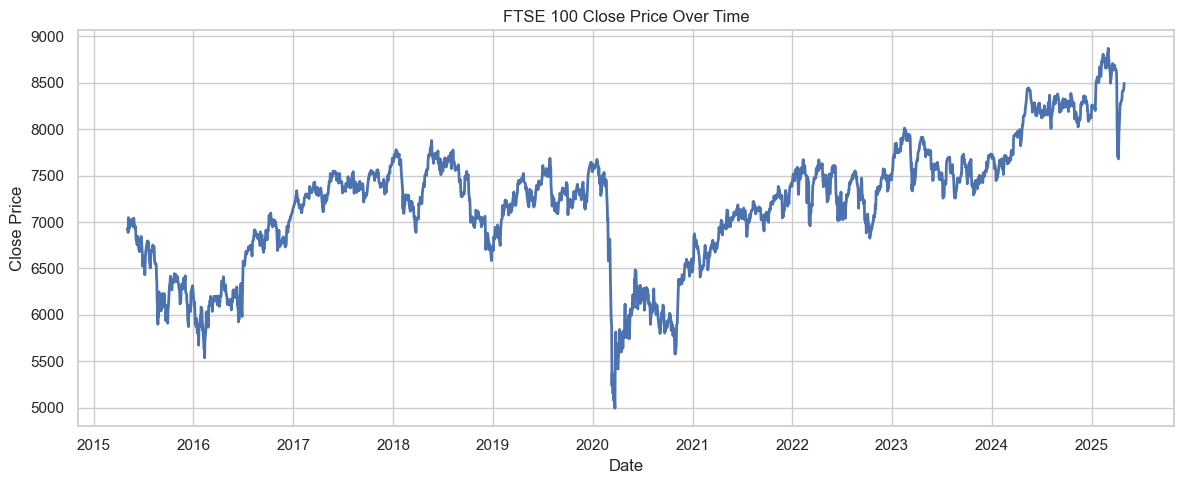

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(diff_stocks_df['Date'], diff_stocks_df['FTSE_100_Close_Price'], label='FTSE 100', linewidth=2)
plt.title('FTSE 100 Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()


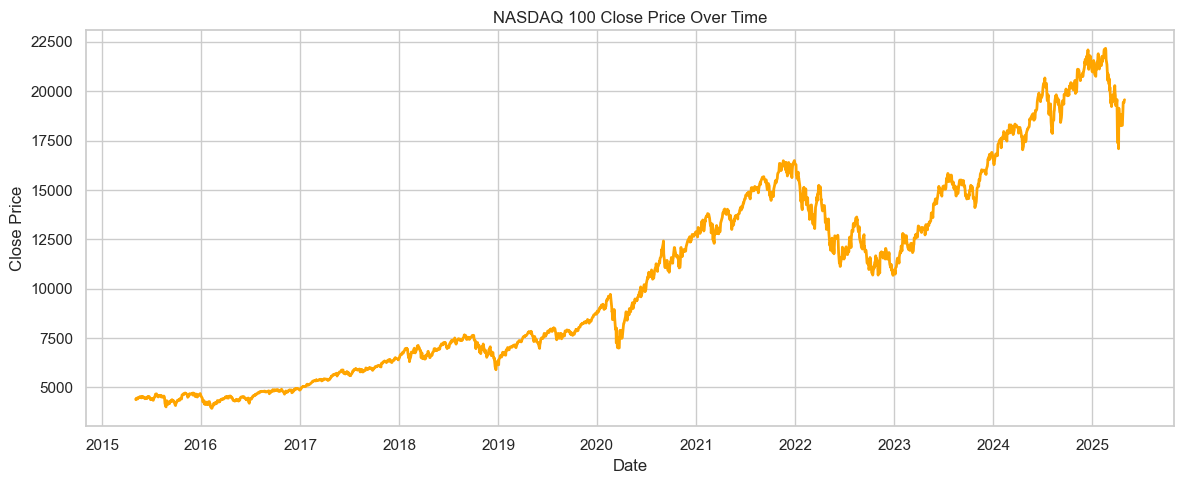

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(diff_stocks_df['Date'], diff_stocks_df['NASDAQ_100_Close_Price'], label='NASDAQ 100', color='orange', linewidth=2)
plt.title('NASDAQ 100 Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
# Ensure 'Date' column is datetime
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'], dayfirst=True, errors='coerce')

# Drop rows with missing or invalid dates
stocks_df = stocks_df.dropna(subset=['Date'])

# Sort by date
stocks_df = stocks_df.sort_values('Date')


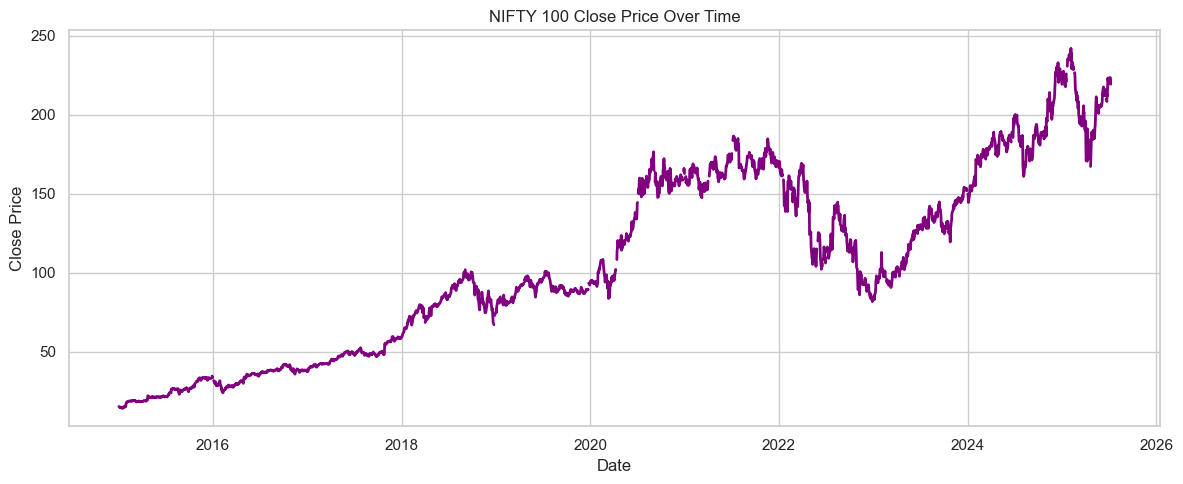

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(stocks_df['Date'], stocks_df['AMZN_CLOSE'], label='Amazon (AMZN)', color='purple', linewidth=2)
plt.title('NIFTY 100 Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()


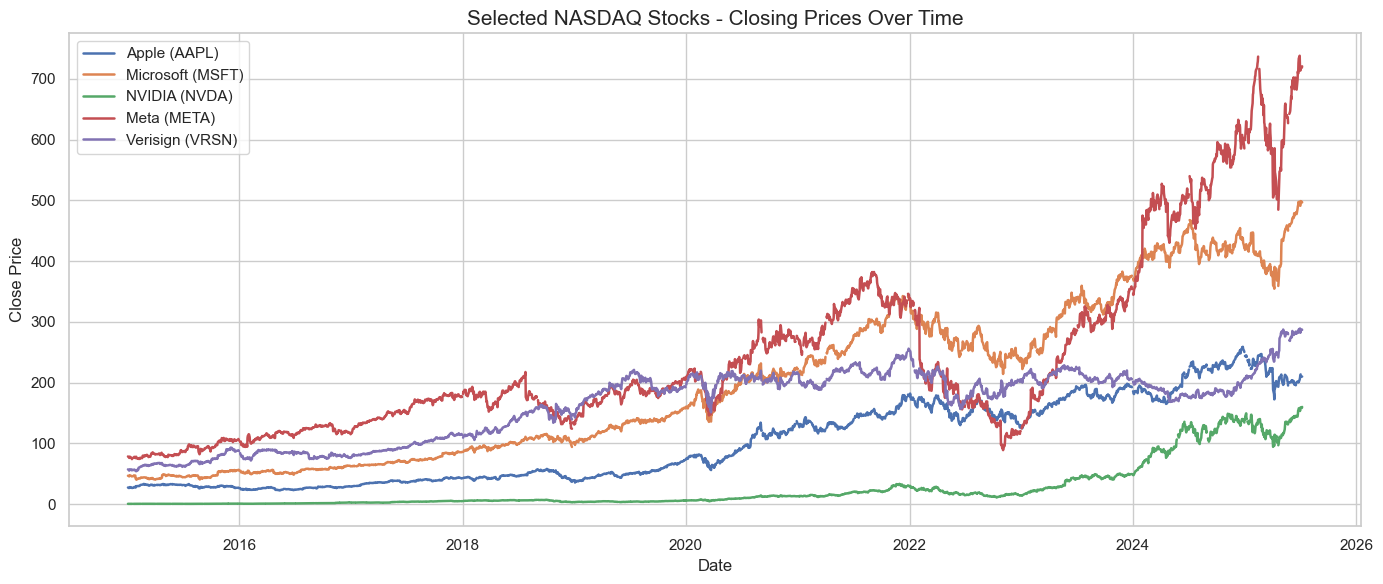

In [29]:
# Convert 'Date' to datetime (if not already done)
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'], dayfirst=True, errors='coerce')

# Drop rows with invalid dates
stocks_df = stocks_df.dropna(subset=['Date'])

# Sort by date
stocks_df = stocks_df.sort_values('Date')
plt.figure(figsize=(14, 6))

# Plot each stock
plt.plot(stocks_df['Date'], stocks_df['AAPL_CLOSE'], label='Apple (AAPL)', linewidth=1.8)
plt.plot(stocks_df['Date'], stocks_df['MSFT_CLOSE'], label='Microsoft (MSFT)', linewidth=1.8)
plt.plot(stocks_df['Date'], stocks_df['NVDA_CLOSE'], label='NVIDIA (NVDA)', linewidth=1.8)
plt.plot(stocks_df['Date'], stocks_df['META_CLOSE'], label='Meta (META)', linewidth=1.8)
plt.plot(stocks_df['Date'], stocks_df['VRSN_CLOSE'], label='Verisign (VRSN)', linewidth=1.8)

# Plot settings
plt.title('Selected NASDAQ Stocks - Closing Prices Over Time', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Outliers

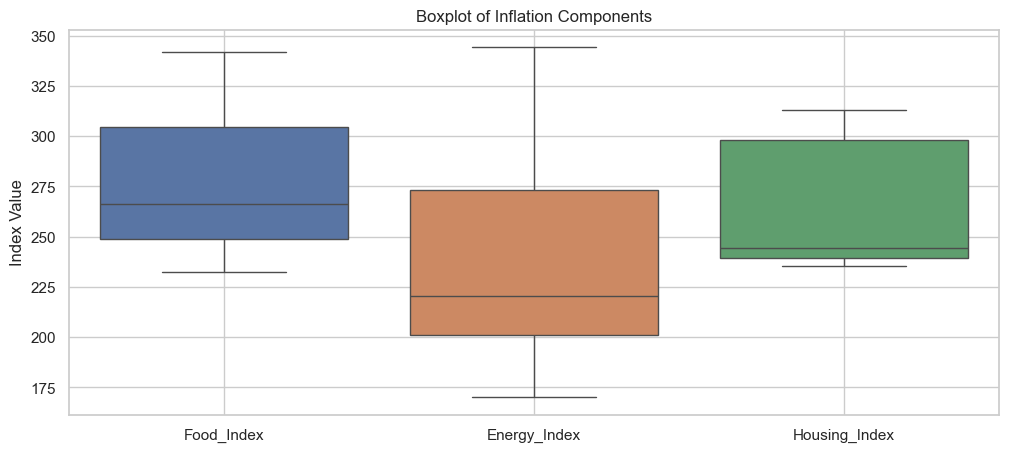

In [30]:
# Plot boxplots for each inflation component
plt.figure(figsize=(12, 5))
sns.boxplot(data=inflation_df[['Food_Index', 'Energy_Index', 'Housing_Index']])
plt.title('Boxplot of Inflation Components')
plt.ylabel('Index Value')
plt.grid(True)
plt.show()

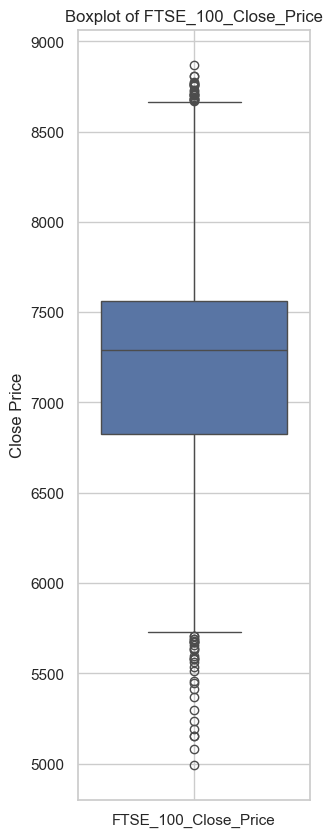

In [40]:
# Boxplot for FTSE, NASDAQ, and NIFTY close prices
plt.figure(figsize=(3, 10))
sns.boxplot(data=diff_stocks_df[['FTSE_100_Close_Price']])
plt.title('Boxplot of FTSE_100_Close_Price')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()


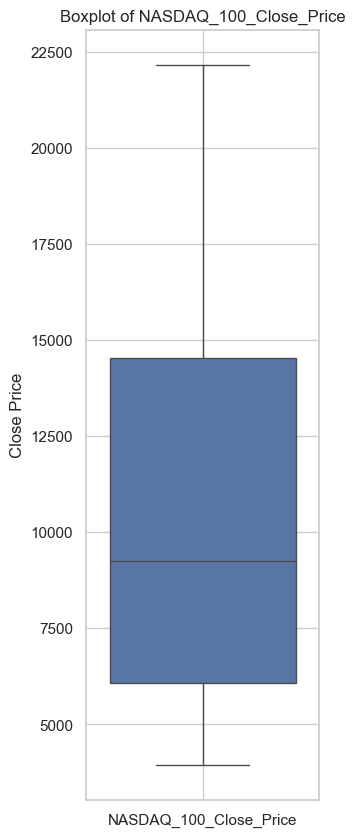

In [41]:
# Boxplot for FTSE, NASDAQ, and NIFTY close prices
plt.figure(figsize=(3, 10))
sns.boxplot(data=diff_stocks_df[['NASDAQ_100_Close_Price']])
plt.title('Boxplot of NASDAQ_100_Close_Price')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()


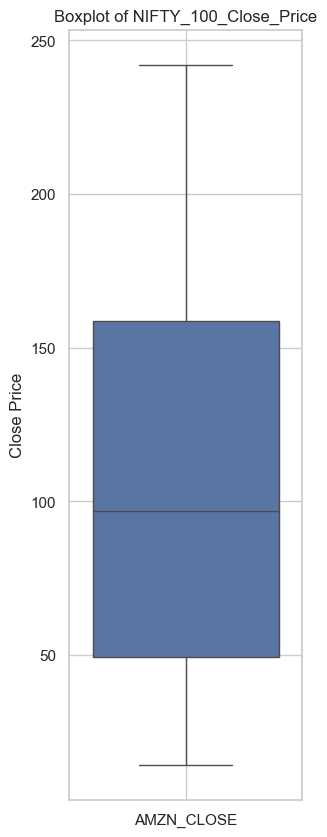

In [44]:
# Boxplot for FTSE, NASDAQ, and NIFTY close prices
plt.figure(figsize=(3, 10))
sns.boxplot(data=stocks_df[['AMZN_CLOSE']])
plt.title('Boxplot of NIFTY_100_Close_Price')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()


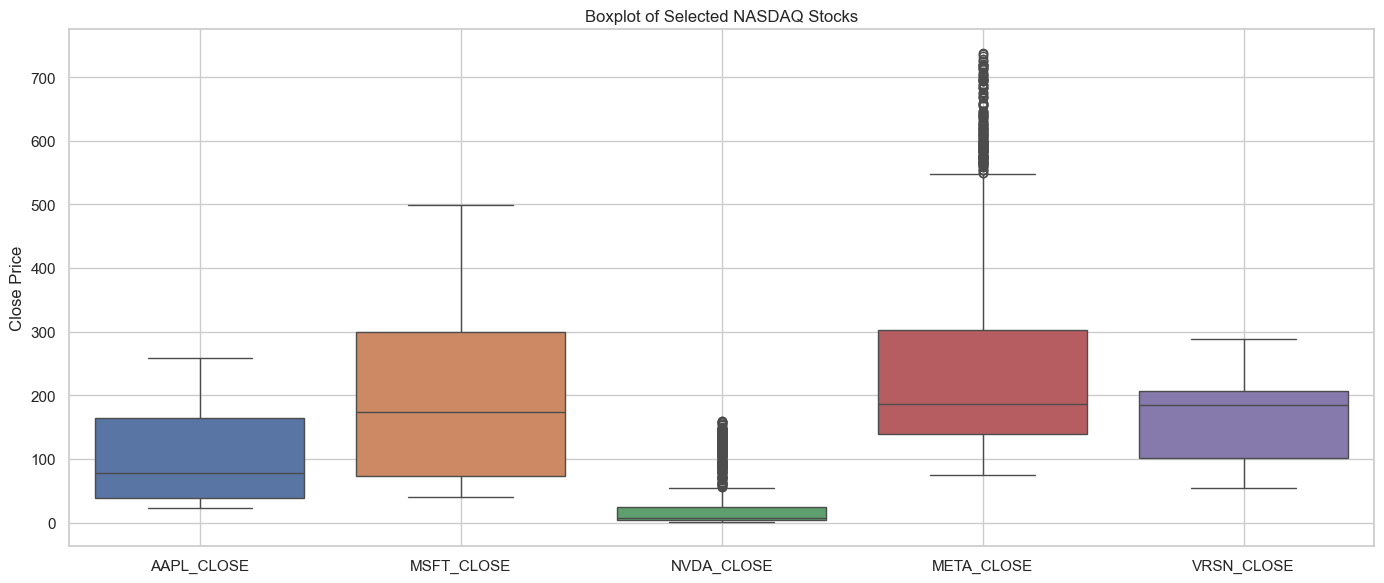

In [45]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=stocks_df[['AAPL_CLOSE', 'MSFT_CLOSE', 'NVDA_CLOSE', 'META_CLOSE', 'VRSN_CLOSE']])
plt.title('Boxplot of Selected NASDAQ Stocks')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()

# skewness and kurtosis

In [46]:
from scipy.stats import skew, kurtosis

In [47]:
# Function to calculate and print skewness & kurtosis
def print_skew_kurt(df, columns, title=""):
    print(f"\n--- {title} ---")
    for col in columns:
        skew_val = skew(df[col].dropna())
        kurt_val = kurtosis(df[col].dropna(), fisher=True)  # Fisher=True means normal dist = 0
        print(f"{col}:  Skewness = {skew_val:.2f},  Kurtosis = {kurt_val:.2f}")

In [49]:
# Inflation indices
print_skew_kurt(inflation_df, ['Food_Index', 'Energy_Index', 'Housing_Index'], title="Inflation Indices")

# Global indices
print_skew_kurt(diff_stocks_df, ['FTSE_100_Close_Price', 'NASDAQ_100_Close_Price'], title="Global Stock Indices")

# NASDAQ stock prices
print_skew_kurt(stocks_df, ['AMZN_CLOSE', 'AAPL_CLOSE', 'MSFT_CLOSE', 'NVDA_CLOSE', 'META_CLOSE', 'VRSN_CLOSE'], title="Selected NASDAQ Stocks")



--- Inflation Indices ---
Food_Index:  Skewness = 0.57,  Kurtosis = -0.99
Energy_Index:  Skewness = 0.55,  Kurtosis = -0.89
Housing_Index:  Skewness = 0.70,  Kurtosis = -1.27

--- Global Stock Indices ---
FTSE_100_Close_Price:  Skewness = -0.31,  Kurtosis = 0.02
NASDAQ_100_Close_Price:  Skewness = 0.50,  Kurtosis = -0.91

--- Selected NASDAQ Stocks ---
AMZN_CLOSE:  Skewness = 0.17,  Kurtosis = -1.09
AAPL_CLOSE:  Skewness = 0.42,  Kurtosis = -1.27
MSFT_CLOSE:  Skewness = 0.46,  Kurtosis = -1.08
NVDA_CLOSE:  Skewness = 1.96,  Kurtosis = 2.55
META_CLOSE:  Skewness = 1.40,  Kurtosis = 1.23
VRSN_CLOSE:  Skewness = -0.39,  Kurtosis = -1.11


In [50]:
# Collect skewness and kurtosis in a dictionary
metrics = {
    'Variable': [],
    'Skewness': [],
    'Kurtosis': []
}

# Combine all columns of interest
columns_to_check = {
    'Inflation Indices': ['Food_Index', 'Energy_Index', 'Housing_Index'],
    'Global Stock Indices': ['FTSE_100_Close_Price', 'NASDAQ_100_Close_Price'],
    'NASDAQ Stocks': ['AMZN_CLOSE', 'AAPL_CLOSE', 'MSFT_CLOSE', 'NVDA_CLOSE', 'META_CLOSE', 'VRSN_CLOSE']
}

# Compute metrics
for group, columns in columns_to_check.items():
    for col in columns:
        metrics['Variable'].append(col)
        metrics['Skewness'].append(skew(stocks_df[col].dropna()) if col in stocks_df else skew(diff_stocks_df[col].dropna()) if col in diff_stocks_df else skew(inflation_df[col].dropna()))
        metrics['Kurtosis'].append(kurtosis(stocks_df[col].dropna()) if col in stocks_df else kurtosis(diff_stocks_df[col].dropna()) if col in diff_stocks_df else kurtosis(inflation_df[col].dropna()))


In [51]:
# Convert to DataFrame
import pandas as pd

metrics_df = pd.DataFrame(metrics)


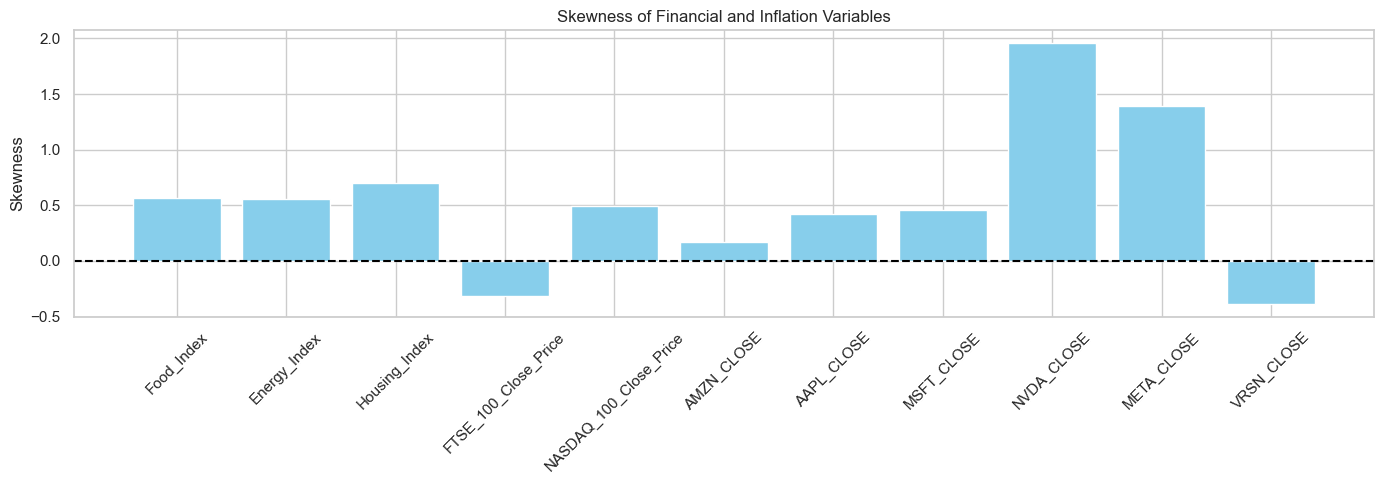

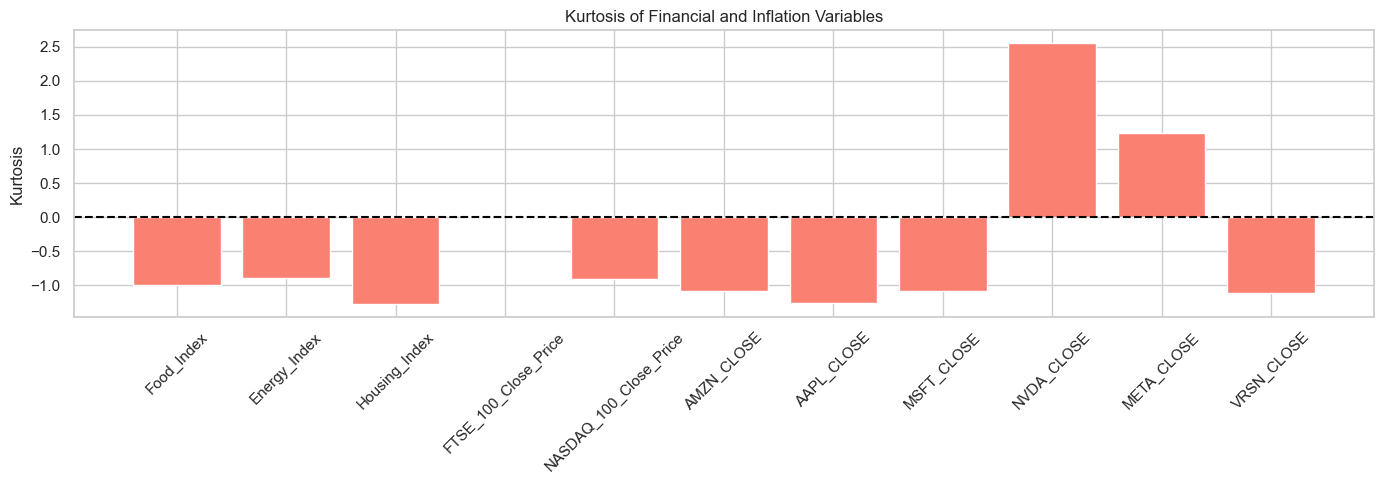

In [52]:
import matplotlib.pyplot as plt

# Bar plot for Skewness
plt.figure(figsize=(14, 5))
plt.bar(metrics_df['Variable'], metrics_df['Skewness'], color='skyblue')
plt.axhline(0, color='black', linestyle='--')
plt.title('Skewness of Financial and Inflation Variables')
plt.xticks(rotation=45)
plt.ylabel('Skewness')
plt.tight_layout()
plt.show()

# Bar plot for Kurtosis
plt.figure(figsize=(14, 5))
plt.bar(metrics_df['Variable'], metrics_df['Kurtosis'], color='salmon')
plt.axhline(0, color='black', linestyle='--')
plt.title('Kurtosis of Financial and Inflation Variables')
plt.xticks(rotation=45)
plt.ylabel('Kurtosis')
plt.tight_layout()
plt.show()
